# Milestone 1 — Exploration & Index Building
**DSCI 575 Advanced Machine Learning**  
**Dataset**: Amazon Reviews 2023 — Grocery and Gourmet Food

This notebook covers:
1. Loading and inspecting the raw dataset (first 200 records for EDA)
2. Selecting and justifying fields for retrieval
3. Demonstrating the tokenization pipeline
4. Building and saving the BM25 index
5. Building and saving the FAISS semantic index

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path so src/ imports work
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import json
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import load_jsonl_gz, tokenize, build_metadata_lookup, build_corpus
from src.bm25 import BM25Retriever
from src.semantic import SemanticRetriever

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 120)

print('All imports OK')

All imports OK


## 1. Load the dataset (first 200 reviews for EDA)

The raw files are `.jsonl.gz` — each line is one JSON record.  
Reviews are capped at 200 for quick EDA as recommended in the milestone.  
Metadata is always loaded in full because reviews and metadata are ordered independently — 
capping metadata at 200 records would produce almost zero `asin` matches, leaving every 
document with no product title after the `build_corpus()` title filter.

In [2]:
RAW_DIR      = PROJECT_ROOT / 'data/raw'
REVIEWS_PATH = RAW_DIR / 'Grocery_and_Gourmet_Food.jsonl.gz'
META_PATH    = RAW_DIR / 'meta_Grocery_and_Gourmet_Food.jsonl.gz'

# Reviews: cap at 200 for EDA.
# Metadata: always load in full — reviews and metadata use different orderings
# so a 200-record metadata cap would almost never overlap with the review ASINs,
# leaving every document with no title after the title filter in build_corpus().
reviews_sample  = load_jsonl_gz(str(REVIEWS_PATH), max_records=200)
metadata_full   = load_jsonl_gz(str(META_PATH))

print(f'Reviews loaded:  {len(reviews_sample)}')
print(f'Metadata loaded: {len(metadata_full)}')

Reviews loaded:  200
Metadata loaded: 603274


## 2. Dataset overview — field names and sizes

In [3]:
print('=== Review record fields ===')
print(list(reviews_sample[0].keys()))
print()
print('=== Metadata record fields ===')
print(list(metadata_full[0].keys()))

=== Review record fields ===
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

=== Metadata record fields ===
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


In [4]:
# Convert to DataFrames for easier inspection
reviews_df  = pd.DataFrame(reviews_sample)
metadata_df = pd.DataFrame(metadata_full[:200])  # slice for display only

print('Reviews DataFrame shape:', reviews_df.shape)
reviews_df.head(3)

Reviews DataFrame shape: (200, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Excellent! Yummy!,Excellent!! Yummy! Great with other foods and great alone.,[],B00CM36GAQ,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1587854482395,0,True
1,5.0,Delicious!!! Yum!,Excellent! The best! I use it with my beef and broccoli and to throw in chicken and rice soup. It’s also great by ...,[],B074J5WVYH,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1587854400380,0,True
2,5.0,"Extremely Delicious, but expensive imo",These are very tasty. They are extremely soft and literally melt on your tongue. The sea salt is delicious. The pac...,[],B079TRNVHX,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1587853224527,1,True


In [5]:
print('Metadata DataFrame shape:', metadata_df.shape)
metadata_df.head(3)

Metadata DataFrame shape: (200, 14)


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Grocery,Dark Roast Pure Coffee,4.7,9,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/51LY15EJoFL._SX38_SY50_CR,0,0,38,50_.jpg', 'large': 'https://m.media...","[{'title': 'YouCut_20220Cafe Du Monde Coffee Chicory, 15 Ounce Ground coffee', 'url': 'https://www.amazon.com/vdp/08...",Luzianne,"[Grocery & Gourmet Food, Beverages, Coffee]","{'Brand': 'Luzianne', 'Item Form': 'Ground', 'Caffeine Content': 'caffeinated', 'Roast Level': 'dark_roast', 'Unit C...",B00NE08WM6,None
1,Grocery,PICARAS Galletas Peruanas Bañadas en Chocolate 6 units x 40 gr. ( 2 Pack ),4.5,12,"[2 Bags of PICARAS Galletas Bañadas en Chocolate 240 g each, 6 units (small bags) of 40 g in each bag | each small b...",[2 Bags of PICARAS Galletas Bañadas en Chocolate 240 gr. (6 units of 40 gr.). Total cookies in each pack 24. Importe...,15.99,"[{'thumb': 'https://m.media-amazon.com/images/I/51gGkM7b1YL._SX38_SY50_CR,0,0,38,50_.jpg', 'large': 'https://m.media...",[],Winters,"[Grocery & Gourmet Food, Breads & Bakery, Cookies, Chocolate]","{'Flavor': 'chocolate', 'Unit Count': '12.00 Count', 'Brand': 'Winters', 'Country/Region Of Origin': 'Peru', 'Item D...",B084Q13Q5Q,None
2,Grocery,Chipped Beef and Gravy By Patterson's - Great for Breakfast or Dinner - 8 Ounce Cans - 6 Cans Per Case,3.2,5,"[Six (6) 8-ounce cans of delicious chipped beef gravy per case, Great over toast, biscuits or pancakes for breakast ...",[Delicious corned beef gravy is ready when you are with these convenient cans from Patterson's. Simply heat and serv...,NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/513F1gCcXrL._SX38_SY50_CR,0,0,38,50_.jpg', 'large': 'https://m.media...",[],Pattersons,"[Grocery & Gourmet Food, Pantry Staples, Canned, Jarred & Packaged Foods, Vegetables, Tomatoes]","{'Package Dimensions': '8.4 x 5.8 x 3.4 inches; 3.75 Pounds', 'UPC': '788128373984', 'Manufacturer': 'Patterson's'}",B00KBRUYVM,None


## 3. Inspect sample records

In [6]:
# Full sample review
print('--- Sample review record ---')
for k, v in reviews_sample[0].items():
    print(f'  {k:20s}: {str(v)[:120]}')

--- Sample review record ---
  rating              : 5.0
  title               : Excellent!  Yummy!
  text                : Excellent!! Yummy!  Great with other foods and great alone.
  images              : []
  asin                : B00CM36GAQ
  parent_asin         : B00CM36GAQ
  user_id             : AFKZENTNBQ7A7V7UXW5JJI6UGRYQ
  timestamp           : 1587854482395
  helpful_vote        : 0
  verified_purchase   : True


In [7]:
# Full sample metadata record
print('--- Sample metadata record ---')
for k, v in metadata_full[0].items():
    print(f'  {k:20s}: {str(v)[:120]}')

--- Sample metadata record ---
  main_category       : Grocery
  title               : Dark Roast Pure Coffee
  average_rating      : 4.7
  rating_number       : 9
  features            : []
  description         : []
  price               : None
  images              : [{'thumb': 'https://m.media-amazon.com/images/I/51LY15EJoFL._SX38_SY50_CR,0,0,38,50_.jpg', 'large': 'https://m.media-ama
  videos              : [{'title': 'YouCut_20220Cafe Du Monde Coffee Chicory, 15 Ounce Ground coffee', 'url': 'https://www.amazon.com/vdp/08a112
  store               : Luzianne
  categories          : ['Grocery & Gourmet Food', 'Beverages', 'Coffee']
  details             : {'Brand': 'Luzianne', 'Item Form': 'Ground', 'Caffeine Content': 'caffeinated', 'Roast Level': 'dark_roast', 'Unit Count
  parent_asin         : B00NE08WM6
  bought_together     : None


## 4. Exploratory Data Analysis

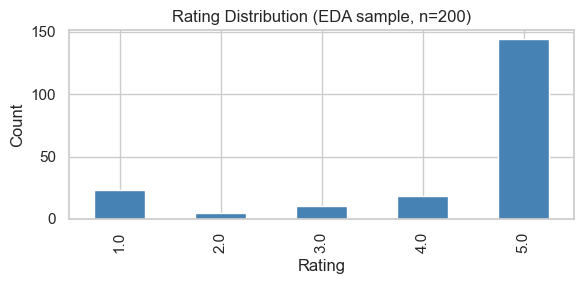

count    200.000000
mean       4.275000
std        1.355938
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: rating, dtype: float64


In [8]:
# --- Rating distribution ---
if 'rating' in reviews_df.columns:
    fig, ax = plt.subplots(figsize=(6, 3))
    reviews_df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Rating Distribution (EDA sample, n=200)')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(reviews_df['rating'].describe())

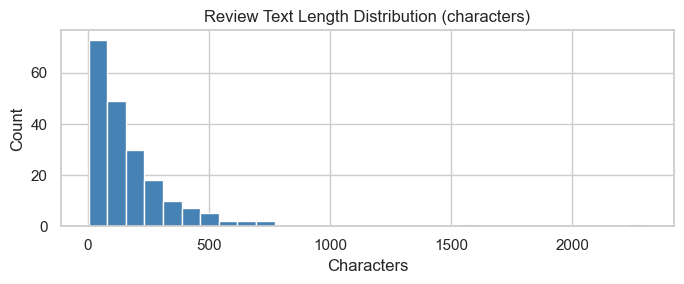

count     200.000000
mean      181.760000
std       234.023068
min         5.000000
25%        58.750000
50%       114.000000
75%       228.750000
max      2305.000000
Name: text_len, dtype: float64


In [9]:
# --- Review text length distribution ---
if 'text' in reviews_df.columns:
    reviews_df['text_len'] = reviews_df['text'].fillna('').apply(len)
    fig, ax = plt.subplots(figsize=(7, 3))
    reviews_df['text_len'].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Review Text Length Distribution (characters)')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(reviews_df['text_len'].describe())

In [10]:
# --- Null / missing field audit ---
print('=== Review field completeness ===')
print(reviews_df.isnull().mean().round(3).to_string())
print()
print('=== Metadata field completeness ===')
print(metadata_df.isnull().mean().round(3).to_string())

=== Review field completeness ===
rating               0.0
title                0.0
text                 0.0
images               0.0
asin                 0.0
parent_asin          0.0
user_id              0.0
timestamp            0.0
helpful_vote         0.0
verified_purchase    0.0
text_len             0.0

=== Metadata field completeness ===
main_category      0.020
title              0.000
average_rating     0.000
rating_number      0.000
features           0.000
description        0.000
price              0.495
images             0.000
videos             0.000
store              0.025
categories         0.000
details            0.000
parent_asin        0.000
bought_together    1.000


## 5. Field selection and justification

We construct one document per review, merging in product metadata via `asin`/`parent_asin`.

| Source   | Field         | Why we include it |
|----------|---------------|-------------------|
| Metadata | `title`       | Product name — brand, flavour, format keywords (e.g. "Organic Extra Virgin Olive Oil") |
| Metadata | `description` | Manufacturer text — dietary claims, ingredient highlights |
| Metadata | `features`    | Bullet-point attributes — certifications (organic, gluten-free, vegan, kosher) and sizes |
| Review   | `title`       | User headline — concise taste/quality verdict |
| Review   | `text`        | Full review body — taste notes, use cases, comparisons, context |

All five fields are concatenated into a single `combined_text` string per document.
This ensures BM25 can match exact keywords from product names *and* semantic search can capture
subjective language from user reviews.

In [11]:
# Build corpus from EDA sample and inspect a few documents
# Use metadata_full for the lookup — reviews_sample ASINs won't match
# a metadata_sample since the two files are ordered independently.
lookup_sample = build_metadata_lookup(metadata_full)
docs_sample   = build_corpus(reviews_sample, lookup_sample)

print(f'Documents built from sample: {len(docs_sample)}')
print()

# Show first 3 documents
for doc in docs_sample[:3]:
    print('ASIN  :', doc['asin'])
    print('Title :', doc['title'])
    print('Rating:', doc['rating'])
    print('Combined text (first 300 chars):')
    print(' ', doc['combined_text'][:300])
    print()

Documents built from sample: 107

ASIN  : B00CM36GAQ
Title : Veetee Thai Jasmine Rice - 2 Minute Rice Microwavable Meals - Instant Rice Meals Ready to Eat Gluten Free Precooked Rice - 10.6 Ounce (Pack of 6)
Rating: 5.0
Combined text (first 300 chars):
  Veetee Thai Jasmine Rice - 2 Minute Rice Microwavable Meals - Instant Rice Meals Ready to Eat Gluten Free Precooked Rice - 10.6 Ounce (Pack of 6) Veetee Dine In Thai Jasmine rice is a sticky, subtly flavored rice ideal for your Asian inspired meals. Grown in Thailand, its unique sticky texture makes

ASIN  : B079TRNVHX
Title : Tara's All Natural Handcrafted Gourmet Sea Salt Caramel: Small Batch, Kettle Cooked, Creamy & Individually Wrapped - 11.5 Ounce
Rating: 5.0
Combined text (first 300 chars):
  Tara's All Natural Handcrafted Gourmet Sea Salt Caramel: Small Batch, Kettle Cooked, Creamy & Individually Wrapped - 11.5 Ounce Taras old-fashioned caramels are made from a century-old family recipe that has not changed. We still cook each ba

## 6. Text preprocessing / tokenization

The `tokenize()` function in `src/utils.py` follows the approach from Lecture 5:

```python
text = text.lower()
text = re.sub(r"[^a-z0-9\s-]", "", text)   # remove punctuation, keep hyphens
tokens = text.split()
# optionally remove stopwords
```

We apply the **same tokenizer** at index-build time and at query time so that BM25's term-frequency statistics are consistent.

In [12]:
# Demonstrate tokenization
example_texts = [
    "Organic Extra-Virgin Olive Oil, Cold Pressed!",
    "Smooth dark chocolate with 70% cocoa — not too sweet.",
    "Great for kids; parents will love it too :)",
]

for text in example_texts:
    tokens_with_sw    = tokenize(text, remove_stopwords=False)
    tokens_without_sw = tokenize(text, remove_stopwords=True)
    print(f'Input  : {text}')
    print(f'With SW: {tokens_with_sw}')
    print(f'No SW  : {tokens_without_sw}')
    print()

Input  : Organic Extra-Virgin Olive Oil, Cold Pressed!
With SW: ['organic', 'extra-virgin', 'olive', 'oil', 'cold', 'pressed']
No SW  : ['organic', 'extra-virgin', 'olive', 'oil', 'cold', 'pressed']

Input  : Smooth dark chocolate with 70% cocoa — not too sweet.
With SW: ['smooth', 'dark', 'chocolate', 'with', '70', 'cocoa', 'not', 'too', 'sweet']
No SW  : ['smooth', 'dark', 'chocolate', '70', 'cocoa', 'sweet']

Input  : Great for kids; parents will love it too :)
With SW: ['great', 'for', 'kids', 'parents', 'will', 'love', 'it', 'too']
No SW  : ['great', 'kids', 'parents', 'love']



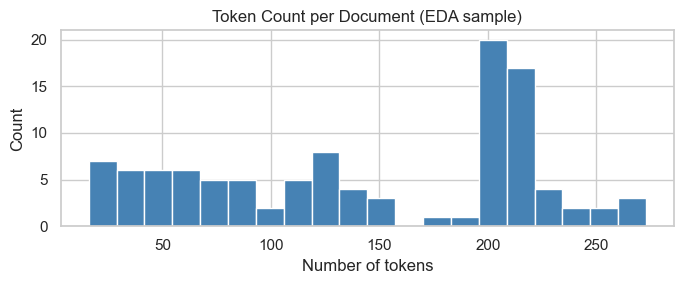

Mean tokens: 143.5  |  Median: 143.0


In [13]:
# Token length distribution on the EDA sample
token_counts = [len(tokenize(doc['combined_text'])) for doc in docs_sample]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(token_counts, bins=20, color='steelblue', edgecolor='white')
ax.set_title('Token Count per Document (EDA sample)')
ax.set_xlabel('Number of tokens')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Mean tokens: {np.mean(token_counts):.1f}  |  Median: {np.median(token_counts):.1f}')

## 7. Quick search demo on the EDA sample

Before building the full index, we verify both retrieval methods work on the 200-record sample.

In [14]:
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import re

# Replicate the exact Lecture 5 demo pattern on our corpus
def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s-]", "", text)
    return text.split()

products          = [doc['combined_text'] for doc in docs_sample]
tokenized_products = [simple_tokenize(p) for p in products]

bm25_demo = BM25Okapi(tokenized_products)

model_demo        = SentenceTransformer('all-MiniLM-L6-v2')
product_embeddings = model_demo.encode(products)

def bm25_search_demo(query, top_k=3):
    tokenized_query = simple_tokenize(query)
    scores          = bm25_demo.get_scores(tokenized_query)
    ranked_idx      = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [(docs_sample[i]['title'] or docs_sample[i]['combined_text'][:80], scores[i])
            for i in ranked_idx]

def embedding_search_demo(query, top_k=3):
    query_embedding = model_demo.encode([query])
    scores          = cosine_similarity(query_embedding, product_embeddings)[0]
    ranked_idx      = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [(docs_sample[i]['title'] or docs_sample[i]['combined_text'][:80], scores[i])
            for i in ranked_idx]

queries_demo = [
    'organic olive oil',
    'snack that tastes sweet but is low in sugar',
]

for q in queries_demo:
    print('=' * 70)
    print(f'QUERY: {q}\n')
    print('BM25 top results:')
    for rank, (title, score) in enumerate(bm25_search_demo(q), start=1):
        print(f'  {rank}. ({score:.3f}) {title}')
    print('\nEmbedding search top results:')
    for rank, (title, score) in enumerate(embedding_search_demo(q), start=1):
        print(f'  {rank}. ({score:.3f}) {title}')
    print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


QUERY: organic olive oil

BM25 top results:
  1. (10.616) Santa Cruz ORGANIC Creamy Dark Roasted Peanut Butter, 16 Oz
  2. (6.276) Starwest Botanicals Organic Ground Cumin Seed Powder, 1 Pound Bulk Spice
  3. (5.680) LouAna Pure Coconut Oil (All Natural) 30 fl oz

Embedding search top results:
  1. (0.412) 365 by Whole Foods Market, Ravioli Eggplant Organic, 8 Ounce
  2. (0.400) Chicken Fry – Box 22 oz
  3. (0.399) LouAna Pure Coconut Oil (All Natural) 30 fl oz

QUERY: snack that tastes sweet but is low in sugar

BM25 top results:
  1. (9.814) Amish Country Popcorn | 2-2 lb Bags | 2 lb Bag Red Popcorn Kernels & 2 lb Bag Midnight Blue Popcorn Kernels | Old Fashioned, Non-GMO and Gluten Free
  2. (8.413) Milk Chocolate Raisins | Nestle Raisinets California Raisins Covered in Chocolate | Made with Whole Real Fruit | Pack in Recloseable Candy Bag | Ideal as a Movie Theater Snack, 2 Packs of 8 Oz
  3. (7.871) Evol Fire Grilled Steak, Single Serve, Gluten Free, 18 Grams of Protein Per Servin

## 8. Build and save the BM25 index (full dataset)

We now load the full raw files, build the corpus, and persist both indexes to `data/processed/`.

> **Note**: adjust `MAX_DOCS` based on your hardware. Start with 10 000–20 000 to test, then increase.

In [15]:
MAX_DOCS = 20_000   # adjust as needed

print(f'Loading up to {MAX_DOCS:,} reviews ...')
reviews_full = load_jsonl_gz(str(REVIEWS_PATH), max_records=MAX_DOCS)

# metadata_full was already loaded in cell 1 — reuse it
lookup_full = build_metadata_lookup(metadata_full)
docs_full   = build_corpus(reviews_full, lookup_full)

print(f'\nFull corpus size: {len(docs_full):,} documents')

Loading up to 20,000 reviews ...

Full corpus size: 9,633 documents


In [16]:
PROCESSED_DIR = PROJECT_ROOT / 'data/processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

bm25_retriever = BM25Retriever()
bm25_retriever.build_index(docs_full)
bm25_retriever.save(str(PROCESSED_DIR / 'bm25_index.pkl'))

Tokenising 9633 documents ...
Building BM25Okapi index ...
BM25 index ready — 9633 documents indexed.
BM25 index saved → C:\Users\rogan\Desktop\575\labs\DSCI_575_project_roganci\data\processed\bm25_index.pkl


## 9. Build and save the FAISS semantic index

In [17]:
sem_retriever = SemanticRetriever()   # loads all-MiniLM-L6-v2
sem_retriever.build_index(docs_full)  # encodes + builds FAISS IndexFlatIP
sem_retriever.save(
    index_path=str(PROCESSED_DIR / 'semantic.index'),
    docs_path=str(PROCESSED_DIR / 'semantic_docs.pkl'),
)

Loading sentence-transformer model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 9633 documents with bert ...


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

FAISS index ready — 9633 vectors, dim=384
FAISS index saved  → C:\Users\rogan\Desktop\575\labs\DSCI_575_project_roganci\data\processed\semantic.index
Documents saved    → C:\Users\rogan\Desktop\575\labs\DSCI_575_project_roganci\data\processed\semantic_docs.pkl


## 10. Verify both indexes with test queries

In [18]:
test_queries = [
    'organic olive oil',
    'coffee that is smooth and not bitter',
    'snack that tastes sweet but is low in sugar',
]

for q in test_queries:
    print('=' * 70)
    print(f'QUERY: {q}\n')

    bm25_results = bm25_retriever.search(q, top_k=3)
    print('BM25 top results:')
    for r in bm25_results:
        print(f'  {r["rank"]}. ({r["score"]:.3f}) {r["title"]}')

    sem_results = sem_retriever.search(q, top_k=3)
    print('\nSemantic search top results:')
    for r in sem_results:
        print(f'  {r["rank"]}. ({r["score"]:.4f}) {r["title"]}')
    print()

QUERY: organic olive oil

BM25 top results:
  1. (18.490) Planeta Extra Virgin Olive Oil, 16.91-Ounce Bottle (Pack of 3)
  2. (18.426) Organic Doctor Organic Virgin Olive Oil Day Cream, 1.7 fl.oz.
  3. (18.079) Organic Italian High Polyphenols (+900mg/kg) Extra Virgin Olive Oil DOP Chianti Classico from Tuscany, Italy | 2022 Harvest, Lab Tested Nutritional Values, Early Harvest | 16.9 fl oz

Semantic search top results:
  1. (0.7719) Organic Italian Extra Virgin Olive Oil from Sicily, Italy | 2022 Harvest, Polyphenol Rich (+300mg/kg), Lab Tested Nutritional Values, Early Harvest | 16.9 fl oz
  2. (0.7406) Organic Doctor Organic Virgin Olive Oil Day Cream, 1.7 fl.oz.
  3. (0.7213) OrganicOrganic Extra Virgin Organic Olive Oil - Certified - Imported -Vegan – Awarded for Great Taste -Fresh Harvest-BIO- Premium Extra Virgin - Cold Pressed -High Phenolic EVOO -Greek- Health- No Pesticides -Your body will be free of chemical agents

QUERY: coffee that is smooth and not bitter

BM25 top resul

---

**Indexes are ready.** Launch the Streamlit app with:

```bash
streamlit run app/app.py
```